     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 727.7 kB/s eta 0:00:00 eta 0:00:01
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 12.1 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 4.1 MB/s eta 0:00:000m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 9.7 MB/s eta 0:00:000m eta 0:00:010:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


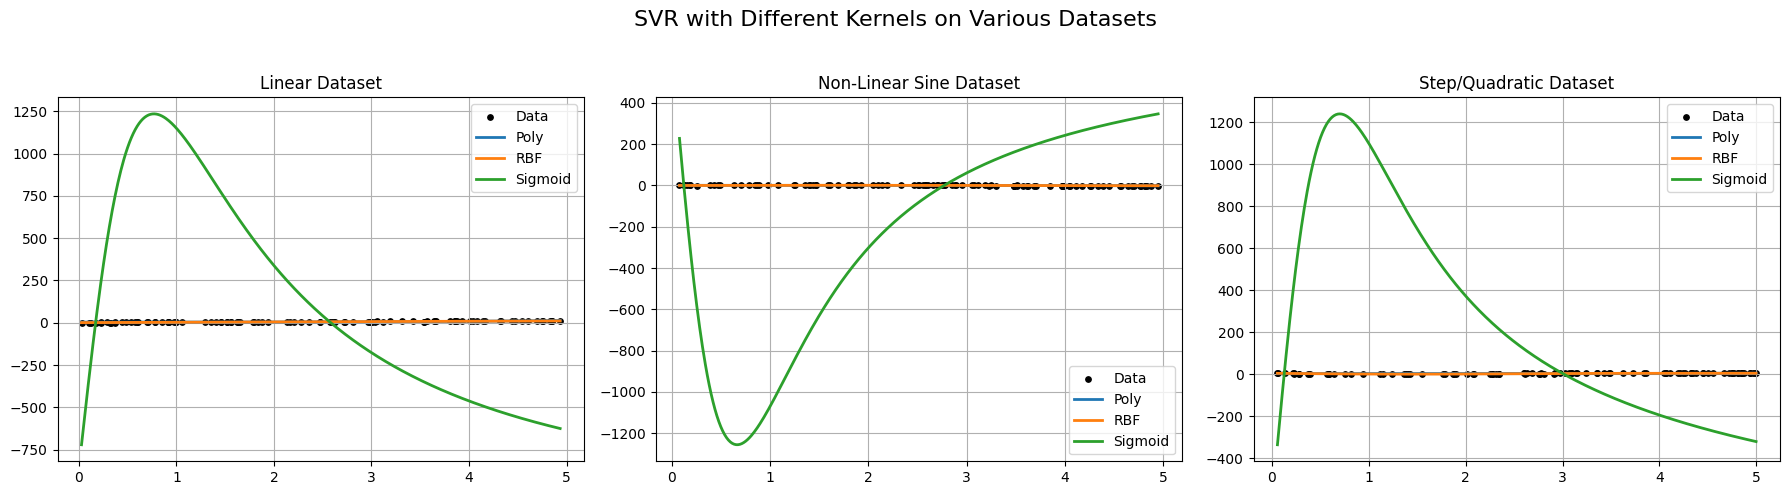

In [6]:
!pip install matplotlib scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# Helper: Train and plot SVR with 3 kernels on a dataset
def train_and_plot(X, y, title, ax):
    svr_poly = SVR(kernel='poly', degree=3, C=100, epsilon=0.1)
    svr_rbf = SVR(kernel='rbf', gamma=0.1, C=100, epsilon=0.1)
    svr_sigmoid = SVR(kernel='sigmoid', C=100, epsilon=0.1)

    svr_poly.fit(X, y)
    svr_rbf.fit(X, y)
    svr_sigmoid.fit(X, y)

    X_test = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
    y_poly = svr_poly.predict(X_test)
    y_rbf = svr_rbf.predict(X_test)
    y_sigmoid = svr_sigmoid.predict(X_test)

    ax.scatter(X, y, color='black', label='Data', s=15)
    ax.plot(X_test, y_poly, label='Poly', linewidth=2)
    ax.plot(X_test, y_rbf, label='RBF', linewidth=2)
    ax.plot(X_test, y_sigmoid, label='Sigmoid', linewidth=2)
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

# Generate 3 datasets
np.random.seed(42)

# Dataset 1: Linear
X1 = np.sort(5 * np.random.rand(100, 1), axis=0)
y1 = 2 * X1.ravel() + 1 + 0.5 * np.random.randn(100)

# Dataset 2: Non-linear (sine wave)
X2 = np.sort(5 * np.random.rand(100, 1), axis=0)
y2 = np.sin(X2).ravel() + 0.2 * np.random.randn(100)

# Dataset 3: Step-like (quadratic)
X3 = np.sort(5 * np.random.rand(100, 1), axis=0)
y3 = np.piecewise(X3.ravel(), [X3.ravel() < 2.5, X3.ravel() >= 2.5], [lambda x: x**2 - 4*x + 4, lambda x: 0.5*x + 2])
y3 += 0.2 * np.random.randn(100)

# Plot all
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

train_and_plot(X1, y1, "Linear Dataset", axs[0])
train_and_plot(X2, y2, "Non-Linear Sine Dataset", axs[1])
train_and_plot(X3, y3, "Step/Quadratic Dataset", axs[2])

plt.suptitle("SVR with Different Kernels on Various Datasets", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()




Polynomial Kernel - Linear Dataset
  MSE : 1.4780
  MAE : 1.0006
  R²  : 0.8243

RBF Kernel - Linear Dataset
  MSE : 0.1285
  MAE : 0.2865
  R²  : 0.9847

Sigmoid Kernel - Linear Dataset
  MSE : 390647.5306
  MAE : 523.8641
  R²  : -46432.6767

Polynomial Kernel - Non-Linear Sine Dataset
  MSE : 0.1063
  MAE : 0.2487
  R²  : 0.8026

RBF Kernel - Non-Linear Sine Dataset
  MSE : 0.0203
  MAE : 0.1068
  R²  : 0.9623

Sigmoid Kernel - Non-Linear Sine Dataset
  MSE : 321901.6489
  MAE : 427.4953
  R²  : -598125.2293

Polynomial Kernel - Step/Quadratic Dataset
  MSE : 2.1536
  MAE : 1.0412
  R²  : 0.2086

RBF Kernel - Step/Quadratic Dataset
  MSE : 0.2355
  MAE : 0.3353
  R²  : 0.9135

Sigmoid Kernel - Step/Quadratic Dataset
  MSE : 323114.3958
  MAE : 426.0889
  R²  : -118735.9476


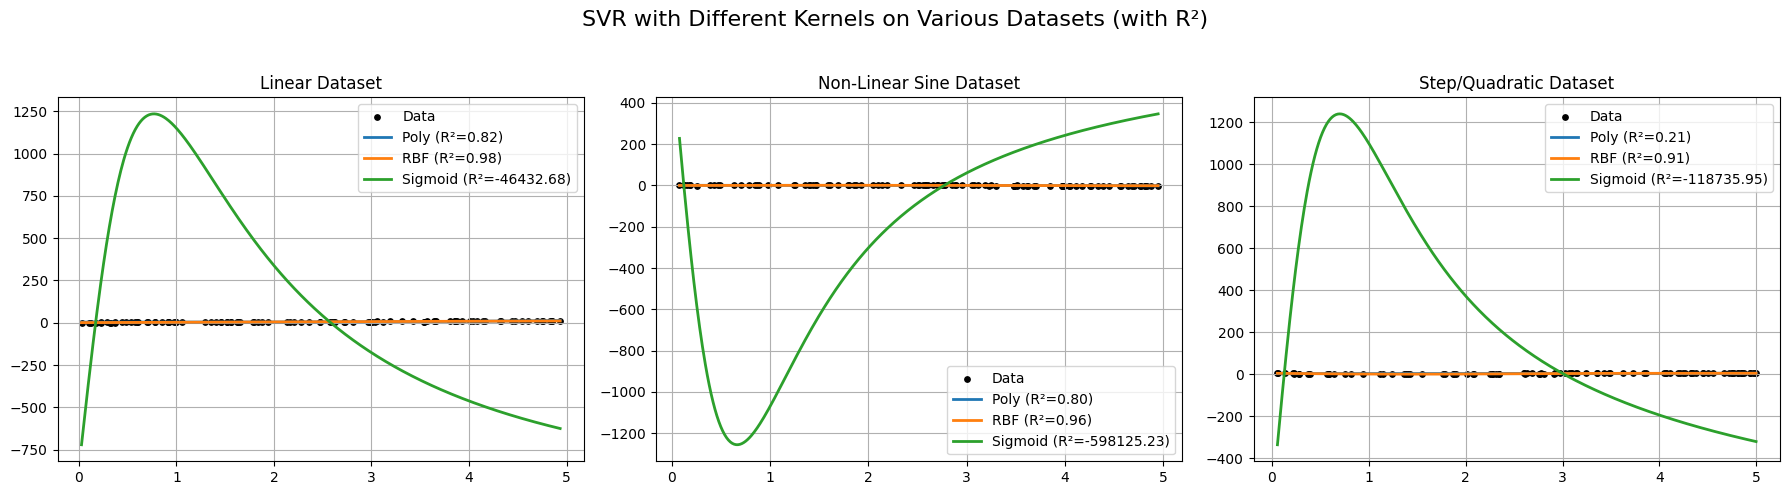

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Helper: Train and plot SVR with 3 kernels on a dataset
def train_and_plot(X, y, title, ax):
    svr_poly = SVR(kernel='poly', degree=3, C=100, epsilon=0.1)
    svr_rbf = SVR(kernel='rbf', gamma=0.1, C=100, epsilon=0.1)
    svr_sigmoid = SVR(kernel='sigmoid', C=100, epsilon=0.1)

    svr_poly.fit(X, y)
    svr_rbf.fit(X, y)
    svr_sigmoid.fit(X, y)

    X_test = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
    y_poly = svr_poly.predict(X_test)
    y_rbf = svr_rbf.predict(X_test)
    y_sigmoid = svr_sigmoid.predict(X_test)

    # True values for performance metrics
    y_true_poly = np.interp(X_test.flatten(), X.flatten(), y)
    y_true_rbf = y_true_poly  # Same true values for all kernels
    y_true_sigmoid = y_true_poly

    # Calculate metrics
    def print_metrics(name, y_true, y_pred):
        print(f"\n{name} Kernel - {title}")
        print(f"  MSE : {mean_squared_error(y_true, y_pred):.4f}")
        print(f"  MAE : {mean_absolute_error(y_true, y_pred):.4f}")
        print(f"  R²  : {r2_score(y_true, y_pred):.4f}")
        return r2_score(y_true, y_pred)

    r2_poly = print_metrics("Polynomial", y_true_poly, y_poly)
    r2_rbf = print_metrics("RBF", y_true_rbf, y_rbf)
    r2_sigmoid = print_metrics("Sigmoid", y_true_sigmoid, y_sigmoid)

    # Plotting
    ax.scatter(X, y, color='black', label='Data', s=15)
    ax.plot(X_test, y_poly, label=f'Poly (R²={r2_poly:.2f})', linewidth=2)
    ax.plot(X_test, y_rbf, label=f'RBF (R²={r2_rbf:.2f})', linewidth=2)
    ax.plot(X_test, y_sigmoid, label=f'Sigmoid (R²={r2_sigmoid:.2f})', linewidth=2)
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

# Generate 3 datasets
np.random.seed(42)

# Dataset 1: Linear
X1 = np.sort(5 * np.random.rand(100, 1), axis=0)
y1 = 2 * X1.ravel() + 1 + 0.5 * np.random.randn(100)

# Dataset 2: Non-linear (sine wave)
X2 = np.sort(5 * np.random.rand(100, 1), axis=0)
y2 = np.sin(X2).ravel() + 0.2 * np.random.randn(100)

# Dataset 3: Step-like (quadratic)
X3 = np.sort(5 * np.random.rand(100, 1), axis=0)
y3 = np.piecewise(X3.ravel(), [X3.ravel() < 2.5, X3.ravel() >= 2.5],
                  [lambda x: x**2 - 4*x + 4, lambda x: 0.5*x + 2])
y3 += 0.2 * np.random.randn(100)

# Plot all
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

train_and_plot(X1, y1, "Linear Dataset", axs[0])
train_and_plot(X2, y2, "Non-Linear Sine Dataset", axs[1])
train_and_plot(X3, y3, "Step/Quadratic Dataset", axs[2])

plt.suptitle("SVR with Different Kernels on Various Datasets (with R²)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
